# FicZon Inc – Sales Effectiveness and Lead Quality Prediction
_________
  
**Client:** Sales Effectiveness  
**Category:** Product Sales

## Business Case

FicZon Inc is an IT solution provider offering products ranging from on-premises solutions to SaaS-based solutions. The company's major lead generation channel is digital and website-based.

Sales effectiveness depends heavily on lead quality. Currently, lead categorization is performed manually and depends significantly on the sales staff. FicZon wants to use Machine Learning to pre-categorize leads based on their quality.

## Project Goals

1. Explore the data and identify insights related to sales effectiveness.
2. Build a Machine Learning model to predict Lead Category:
   - High Potential
   - Low Potential

## Important Modeling Consideration

The `Status` column is used to derive the target variable `Lead_Category`.

Therefore, `Status` must **not** be used as an input feature during Machine Learning because doing so would cause **target leakage**.

## Dataset Information

The dataset is stored in a MySQL database.

- Database Name: `project_sales`
- Table Name: `data`
- Number of Records: 7,422
- Number of Columns: 9

### Features

| Feature | Description |
|---|---|
| Created | Date on which the lead was created |
| Product_ID | Identifier of the product associated with the lead |
| Source | Source through which the lead was generated |
| Mobile | Mobile contact information |
| EMAIL | Email information |
| Sales_Agent | Sales agent handling the lead |
| Location | Location of the lead |
| Delivery_Mode | Delivery mode associated with the lead |
| Status | Current status/outcome of the lead |



> **Note:** The `Status` column is used to derive the target variable `Lead_Category`. Therefore, `Status` is excluded from the Machine Learning feature set to prevent target leakage.

## 1. Import Required Libraries

The libraries required for data loading, data analysis, visualization, preprocessing, Machine Learning, and model evaluation are imported below.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mysql.connector

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

sns.set_style("whitegrid")

## 2. Connect to MySQL Database

The project data is stored in the `project_sales` database and the table used for this project is `data`.

In [ ]:
connection = mysql.connector.connect(
    host="18.136.157.135",
    port=3306,
    user="dm_team2",
    password=input("Enter MySQL password: "),
    database="project_sales"
)

print("Database connection successful.")

Database connection successful.


## 3. Load Data from MySQL

All records from the `data` table are loaded into a Pandas DataFrame.

In [3]:
query = "SELECT * FROM data"

df = pd.read_sql(query, connection)

print("Data loaded successfully.")
print("Shape of dataset:", df.shape)

Data loaded successfully.
Shape of dataset: (7422, 9)


## 4. Understand the Dataset

The dataset contains 7,422 records and 9 original columns.

The columns are:

- Created
- Product_ID
- Source
- Mobile
- EMAIL
- Sales_Agent
- Location
- Delivery_Mode
- Status

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

display(df.head())

Number of rows: 7422
Number of columns: 9


,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,,Mode-5,Open
1,14-11-2018 09:22,,Website,XXXXXXX,#VALUE!,Sales-Agent-10,,Mode-5,Open
2,14-11-2018 09:21,,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,,Mode-5,Open
3,14-11-2018 08:46,,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open
4,14-11-2018 07:34,,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open


In [5]:
df.tail()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
7417,28-04-2018 09:45,9,Call,,aXXXXXXX@gmail.com,Sales-Agent-6,Mumbai,Mode-4,LOST
7418,28-04-2018 09:43,15,Call,,#VALUE!,Sales-Agent-12,Other Locations,Mode-5,LOST
7419,28-04-2018 09:20,5,Live Chat-Direct,,sXXXXXXX@gmail.com,Sales-Agent-11,Bangalore,Mode-1,Not Responding
7420,28-04-2018 08:04,21,CRM form,,YXXXXXXX@gmail.com,Sales-Agent-4,Other Locations,Mode-1,Just Enquiry
7421,28-04-2018 07:54,25,Website,,cXXXXXXX@gmail.com,Sales-Agent-3,Chennai,Mode-1,CONVERTED


## 5. Dataset Information

Check the data types, number of non-null values, and memory usage of the dataset.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7422 entries, 0 to 7421
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Created        7422 non-null   object
 1   Product_ID     7422 non-null   object
 2   Source         7422 non-null   object
 3   Mobile         7422 non-null   object
 4   EMAIL          7422 non-null   object
 5   Sales_Agent    7422 non-null   object
 6   Location       7422 non-null   object
 7   Delivery_Mode  7422 non-null   object
 8   Status         7422 non-null   object
dtypes: object(9)
memory usage: 522.0+ KB


## 6. Check Missing Values

Missing values are checked for every column before performing data preprocessing.

In [7]:
missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

display(missing_values)

,Missing Count,Missing Percentage
Created,0,0.0
Product_ID,0,0.0
Source,0,0.0
Mobile,0,0.0
EMAIL,0,0.0
Sales_Agent,0,0.0
Location,0,0.0
Delivery_Mode,0,0.0
Status,0,0.0


## 7. Check Duplicate Records

Duplicate records are checked to understand whether the dataset contains repeated rows.

In [8]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 2


## 8. Check Unique Values

Unique values are examined for the categorical columns to understand the structure of the data.

In [9]:
for column in df.columns:
    print("\n" + "=" * 50)
    print("Column:", column)
    print("Number of unique values:", df[column].nunique(dropna=True))
    print(df[column].dropna().unique()[:20])


Column: Created
Number of unique values: 6752
['14-11-2018 10:05' '14-11-2018 09:22' '14-11-2018 09:21'
 '14-11-2018 08:46' '14-11-2018 07:34' '14-11-2018 07:33'
 '14-11-2018 05:58' '14-11-2018 05:49' '14-11-2018 05:40'
 '14-11-2018 05:06' '14-11-2018 05:03' '14-11-2018 04:52'
 '14-11-2018 02:37' '13-11-2018 23:40' '13-11-2018 21:14'
 '13-11-2018 20:45' '13-11-2018 20:15' '13-11-2018 20:14'
 '13-11-2018 18:51' '13-11-2018 18:48']

Column: Product_ID
Number of unique values: 30
['' '9' '19' '18' '15' '27' '5' '2' '3' '25' '10' '20' '11' '21' '1' '12'
 '13' '17' '24' '26']

Column: Source
Number of unique values: 26
['Website' '' 'Live Chat-Google Organic' 'Call' 'Live Chat-Direct'
 'By Recommendation' 'Customer Referral' 'Live Chat-Blog' 'Live Chat -PPC'
 'Live Chat-Google Ads' 'Live Chat-Adwords Remarketing' 'E-Mail Message'
 'Existing Client' 'Live Chat-CPC' 'Existing Customer' 'Live Chat-Quora'
 'US Website' 'Just Dial' 'Campaign' 'Other']

Column: Mobile
Number of unique values: 48

# Exploratory Data Analysis

The following business questions are explored:

1. Lead Status Distribution
2. Lead Source Distribution
3. Source vs Status
4. Conversion Rate by Source
5. Sales Agent Analysis
6. Sales Agent vs Status
7. Location Analysis
8. Delivery Mode Analysis
9. Product Analysis
10. Mobile Availability
11. Email Availability
12. Lead creation trend

## 9. Lead Status Distribution

The distribution of lead statuses is analyzed to understand the current sales pipeline.

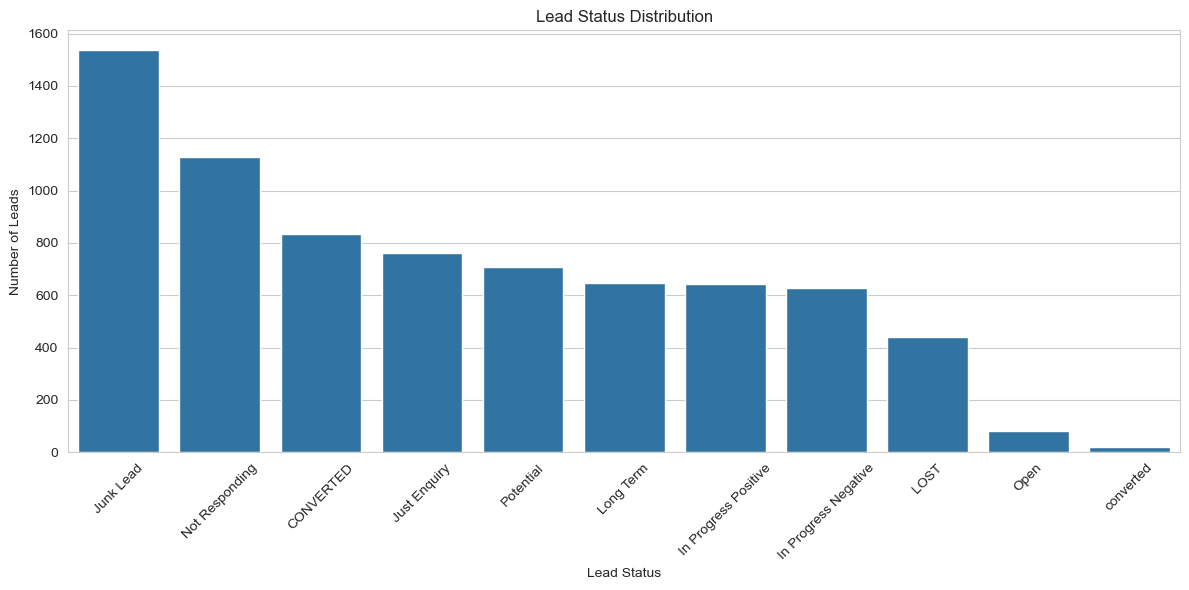

In [10]:
status_counts = df["Status"].value_counts()

plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="Status",
    order=status_counts.index
)

plt.title("Lead Status Distribution")
plt.xlabel("Lead Status")
plt.ylabel("Number of Leads")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. Lead Source Distribution

This analysis identifies the sources generating the highest number of leads.

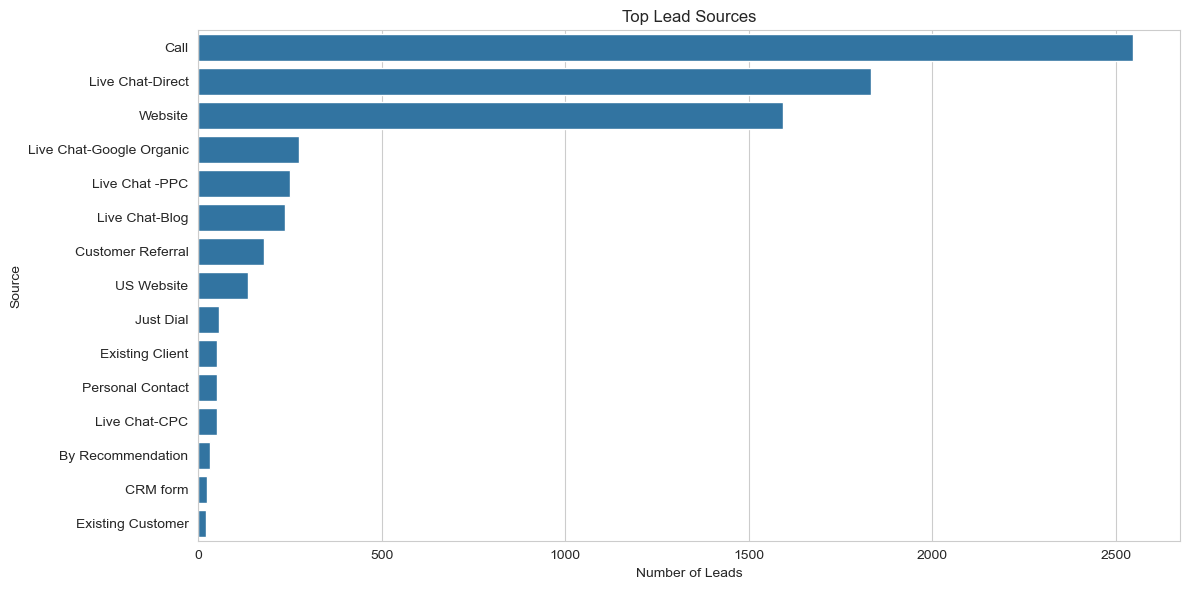

In [11]:
source_counts = df["Source"].value_counts().head(15)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=source_counts.values,
    y=source_counts.index
)

plt.title("Top Lead Sources")
plt.xlabel("Number of Leads")
plt.ylabel("Source")
plt.tight_layout()
plt.show()

## 11. Source vs Status

The relationship between lead source and lead status is analyzed to understand how different sources perform across the sales pipeline.

In [12]:
source_status = pd.crosstab(df["Source"], df["Status"])

display(source_status)

Status,CONVERTED,In Progress Negative,In Progress Positive,Junk Lead,Just Enquiry,LOST,Long Term,Not Responding,Open,Potential,converted
Source,,,,,,,,,,,
,0,1,0,1,1,1,0,2,10,1,0
By Recommendation,18,0,1,0,0,1,4,2,1,5,0
CRM form,3,5,0,3,2,3,0,3,0,4,0
Call,240,200,213,730,217,159,215,308,16,248,1
Campaign,4,0,0,4,0,1,2,6,0,2,0
Customer Referral,118,4,15,4,4,2,5,5,0,21,2
E-Mail Message,0,0,0,0,0,0,0,0,0,1,0
E-mail Campaign,4,2,0,0,0,2,1,3,0,0,0
Existing Client,35,0,2,2,1,0,2,0,0,9,0


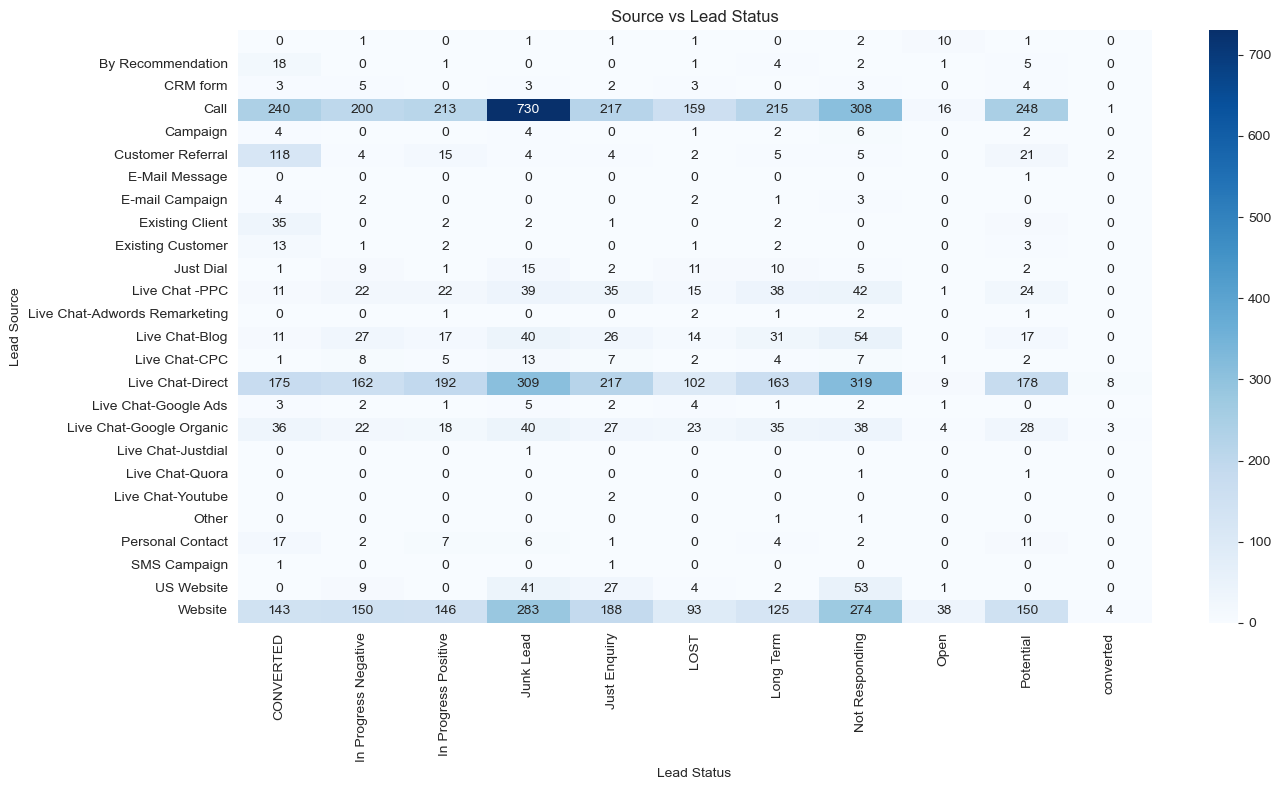

In [13]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    source_status,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Source vs Lead Status")
plt.xlabel("Lead Status")
plt.ylabel("Lead Source")
plt.tight_layout()
plt.show()

## 12. Conversion Rate by Source

Conversion rate is calculated as:

Conversion Rate = Converted Leads / Total Leads × 100

This helps identify lead sources that generate a higher proportion of converted leads.

In [14]:
source_conversion = df.copy()

source_conversion["Is_Converted"] = (
    source_conversion["Status"].str.strip().str.upper() == "CONVERTED"
).astype(int)

conversion_by_source = (
    source_conversion.groupby("Source")["Is_Converted"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "Converted Leads", "count": "Total Leads"})
)

conversion_by_source["Conversion Rate (%)"] = (
    conversion_by_source["Converted Leads"]
    / conversion_by_source["Total Leads"]
    * 100
)

conversion_by_source = conversion_by_source.sort_values(
    "Conversion Rate (%)",
    ascending=False
)

display(conversion_by_source)

,Converted Leads,Total Leads,Conversion Rate (%)
Source,,,
Existing Client,35,51,68.627451
Customer Referral,120,180,66.666667
Existing Customer,13,22,59.090909
By Recommendation,18,32,56.250000
SMS Campaign,1,2,50.000000
Personal Contact,17,50,34.000000
E-mail Campaign,4,12,33.333333
Campaign,4,19,21.052632
Live Chat-Google Ads,3,21,14.285714


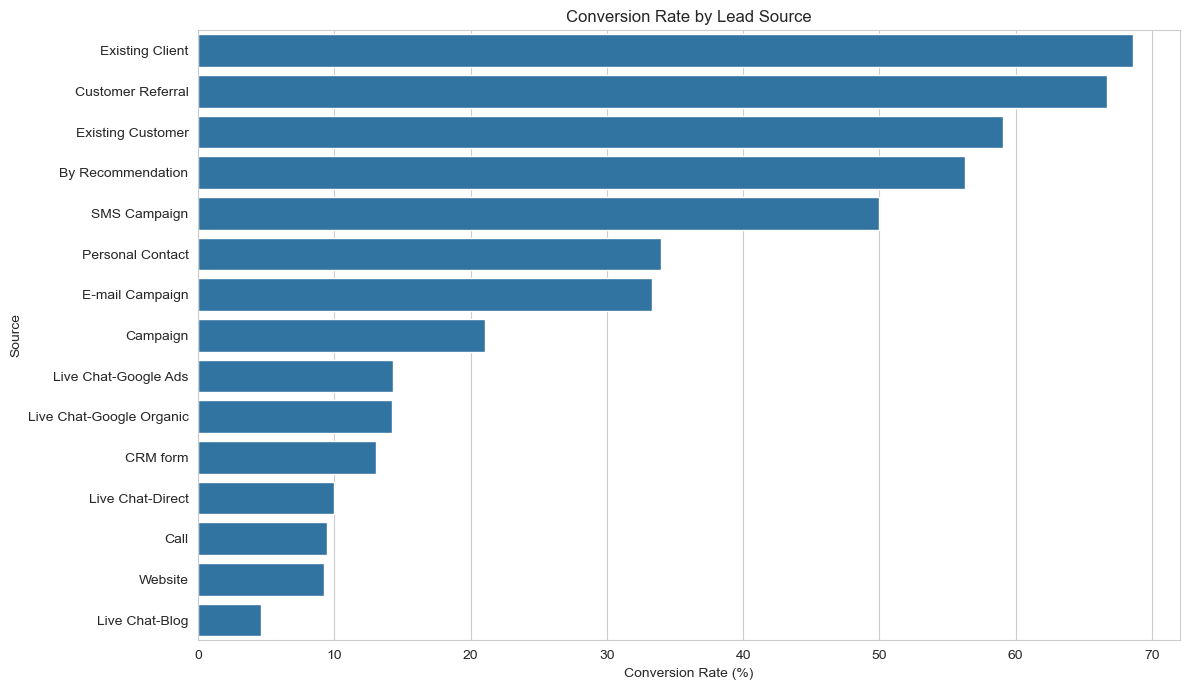

In [15]:
top_conversion_sources = conversion_by_source.head(15)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_conversion_sources.reset_index(),
    x="Conversion Rate (%)",
    y="Source"
)

plt.title("Conversion Rate by Lead Source")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("Source")
plt.tight_layout()
plt.show()

## 13. Sales Agent Analysis

The number of leads handled by each sales agent is analyzed to understand sales workload distribution.

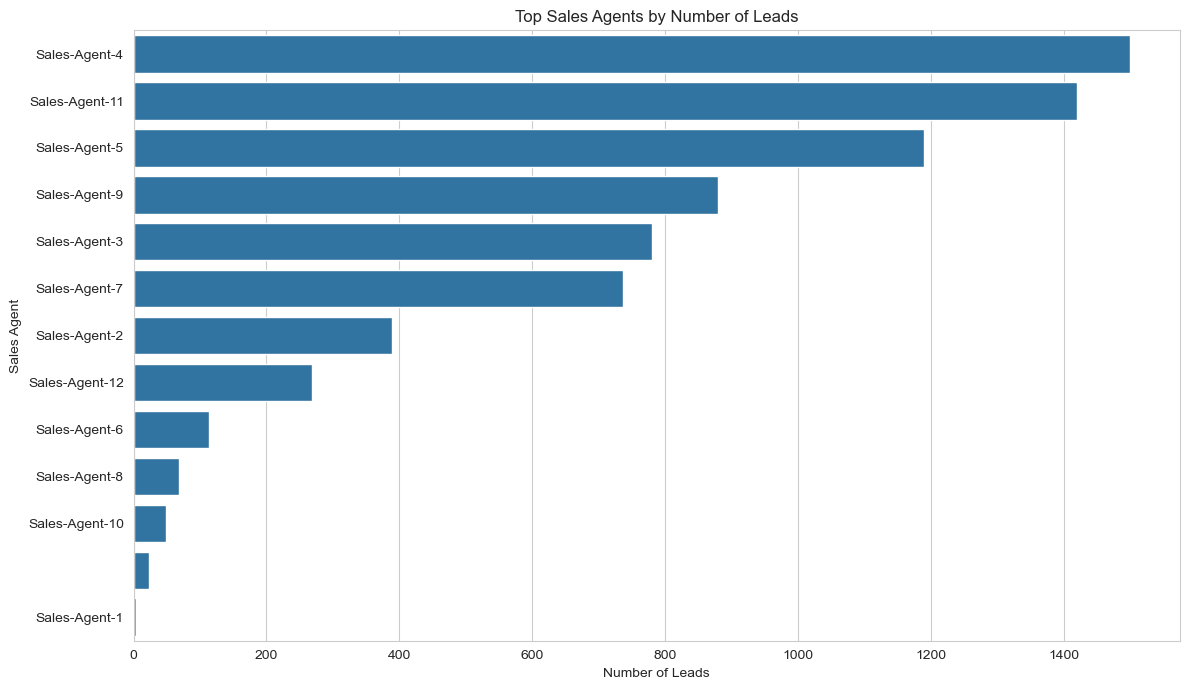

In [16]:
agent_counts = df["Sales_Agent"].value_counts().head(20)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=agent_counts.values,
    y=agent_counts.index
)

plt.title("Top Sales Agents by Number of Leads")
plt.xlabel("Number of Leads")
plt.ylabel("Sales Agent")
plt.tight_layout()
plt.show()

## 14. Sales Agent vs Status

The distribution of lead statuses across sales agents is analyzed.

In [17]:
agent_status = pd.crosstab(df["Sales_Agent"], df["Status"])

display(agent_status)

Status,CONVERTED,In Progress Negative,In Progress Positive,Junk Lead,Just Enquiry,LOST,Long Term,Not Responding,Open,Potential,converted
Sales_Agent,,,,,,,,,,,
,0,0,0,0,4,0,0,3,14,2,0
Sales-Agent-1,0,0,0,0,0,0,0,0,4,0,0
Sales-Agent-10,0,0,0,5,0,0,0,0,44,0,0
Sales-Agent-11,118,119,8,299,219,40,120,246,1,249,1
Sales-Agent-12,82,51,0,79,0,57,0,0,0,0,0
Sales-Agent-2,61,59,0,94,1,45,111,17,0,1,0
Sales-Agent-3,122,81,36,195,69,47,80,109,1,40,1
Sales-Agent-4,131,91,198,303,193,73,73,293,0,145,0
Sales-Agent-5,77,107,3,318,158,106,92,189,1,138,1


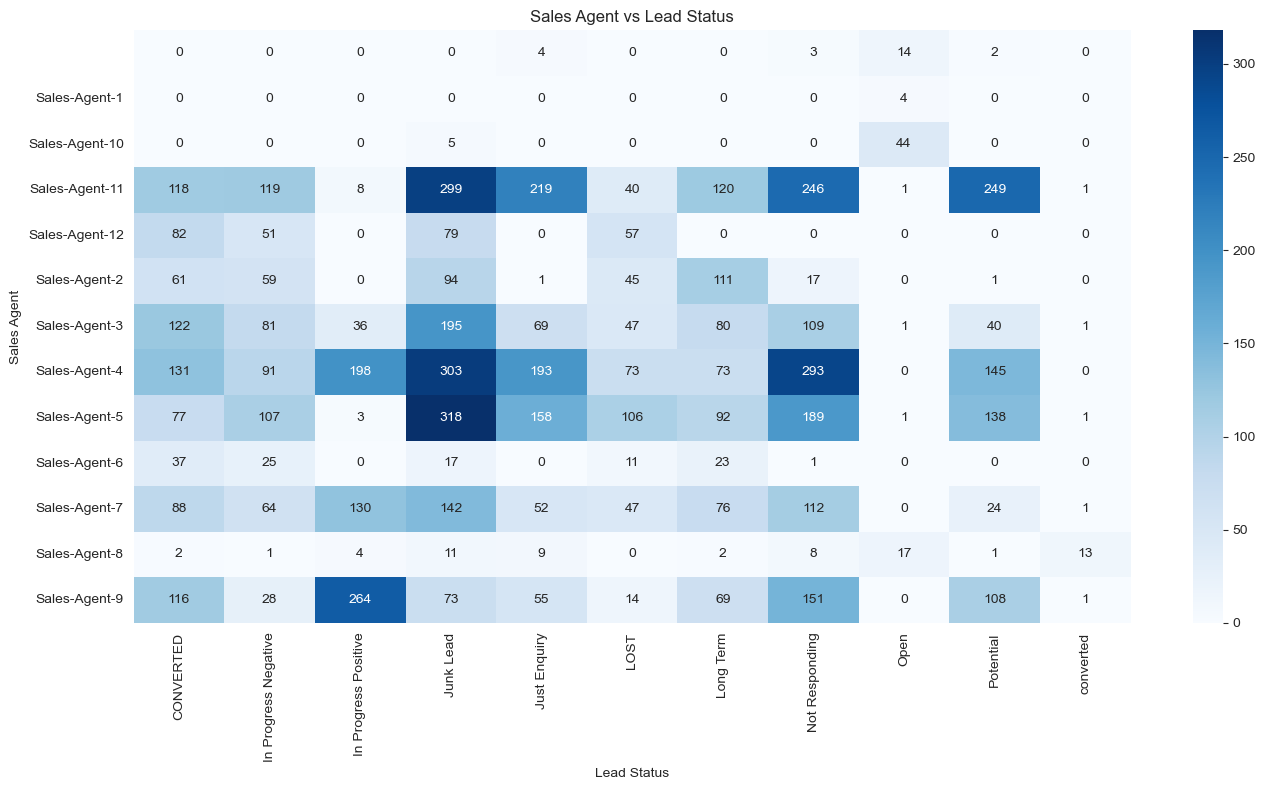

In [18]:
top_agents = df["Sales_Agent"].value_counts().head(15).index

agent_status_top = agent_status.loc[
    agent_status.index.isin(top_agents)
]

plt.figure(figsize=(14, 8))

sns.heatmap(
    agent_status_top,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Sales Agent vs Lead Status")
plt.xlabel("Lead Status")
plt.ylabel("Sales Agent")
plt.tight_layout()
plt.show()

## 15. Location Analysis

The distribution of leads across locations is analyzed to identify regions generating the highest number of leads.

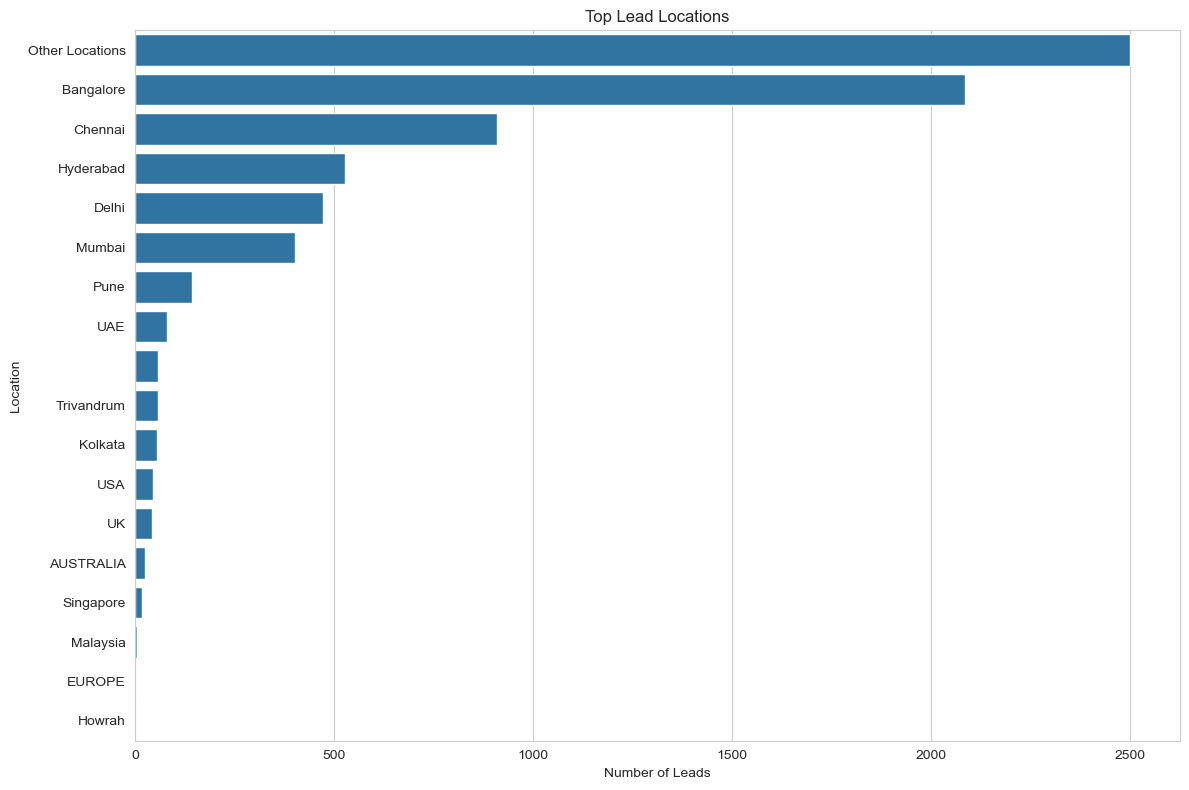

In [19]:
location_counts = df["Location"].value_counts().head(20)

plt.figure(figsize=(12, 8))

sns.barplot(
    x=location_counts.values,
    y=location_counts.index
)

plt.title("Top Lead Locations")
plt.xlabel("Number of Leads")
plt.ylabel("Location")
plt.tight_layout()
plt.show()

## 16. Delivery Mode Analysis

The distribution of leads across different delivery modes is analyzed.

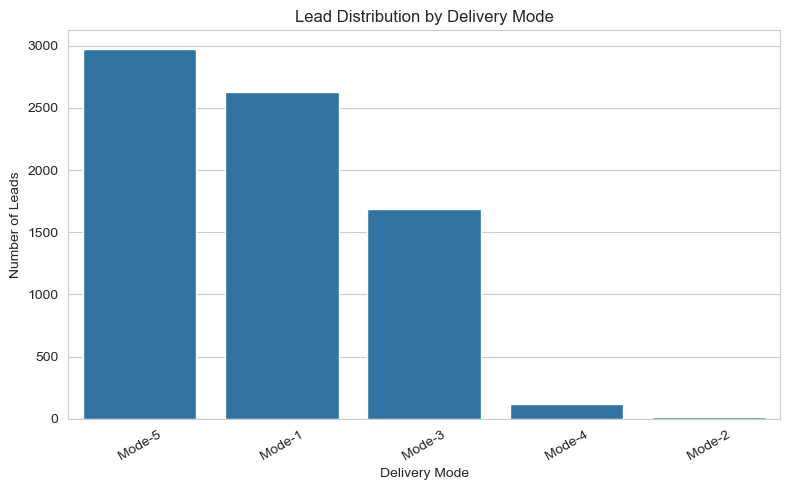

In [20]:
delivery_counts = df["Delivery_Mode"].value_counts()

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Delivery_Mode",
    order=delivery_counts.index
)

plt.title("Lead Distribution by Delivery Mode")
plt.xlabel("Delivery Mode")
plt.ylabel("Number of Leads")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 17. Product Analysis

The number of leads associated with each product is analyzed.

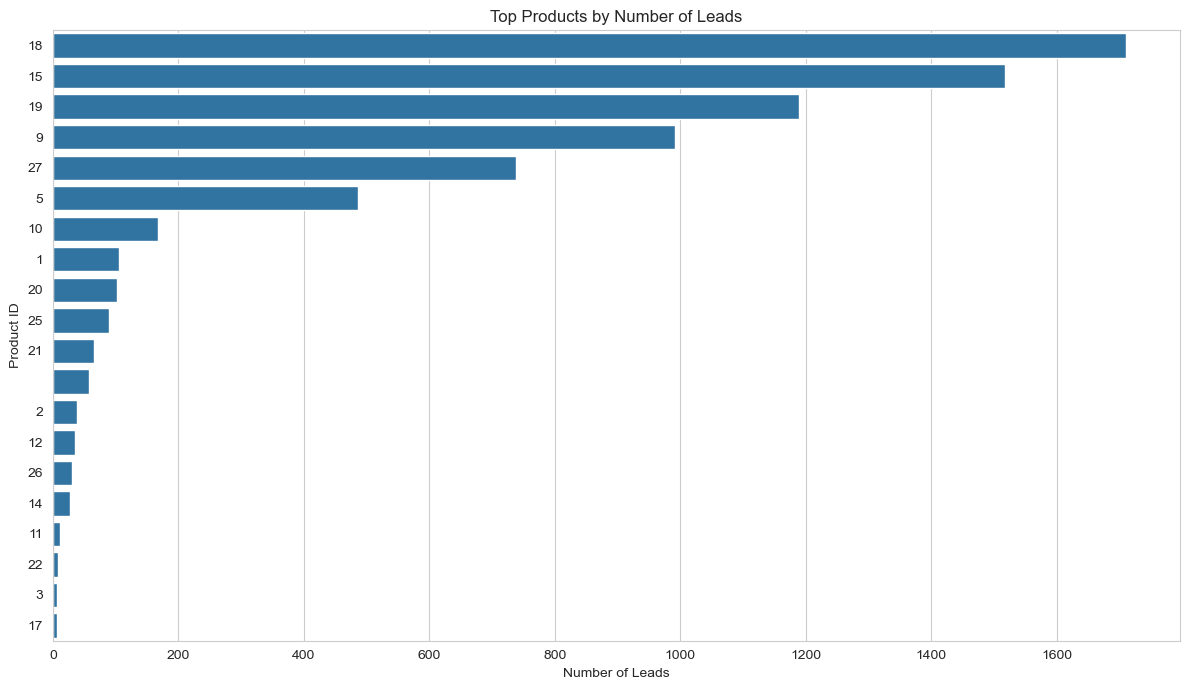

In [21]:
product_counts = df["Product_ID"].value_counts().head(20)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=product_counts.values,
    y=product_counts.index.astype(str)
)

plt.title("Top Products by Number of Leads")
plt.xlabel("Number of Leads")
plt.ylabel("Product ID")
plt.tight_layout()
plt.show()

## 18. Mobile Availability

The availability of mobile contact information is analyzed.

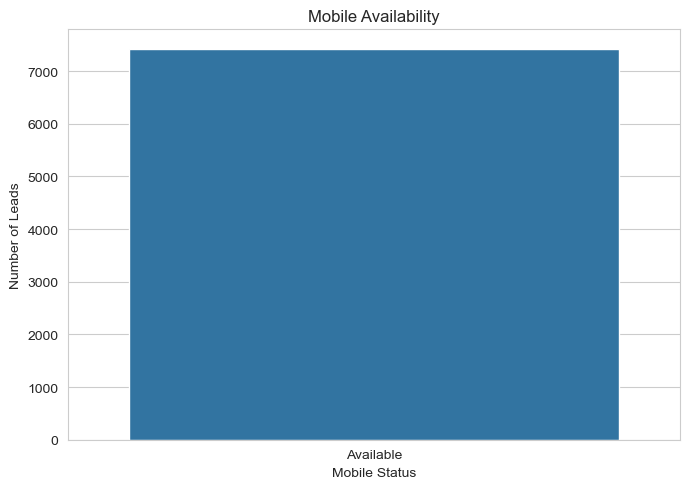

In [22]:
mobile_available = df["Mobile"].notna().map({
    True: "Available",
    False: "Not Available"
})

mobile_counts = mobile_available.value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=mobile_counts.index,
    y=mobile_counts.values
)

plt.title("Mobile Availability")
plt.xlabel("Mobile Status")
plt.ylabel("Number of Leads")
plt.tight_layout()
plt.show()

## 19. Email Availability

The availability of email information is analyzed.

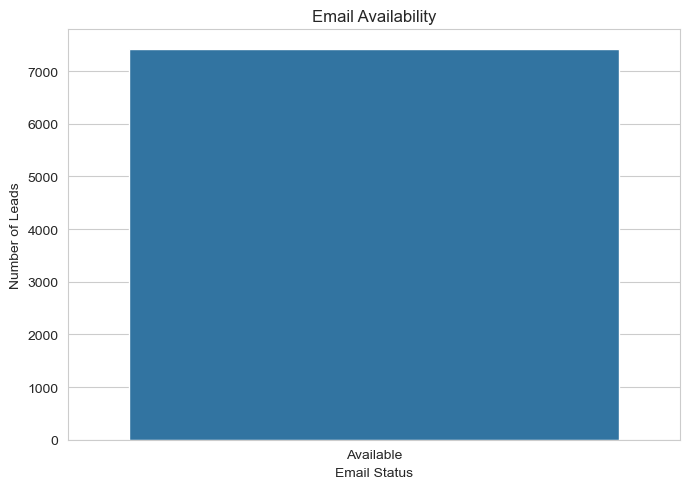

In [23]:
email_available = (
    df["EMAIL"]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
)

email_status = email_available.map({
    True: "Available",
    False: "Not Available"
})

email_counts = email_status.value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=email_counts.index,
    y=email_counts.values
)

plt.title("Email Availability")
plt.xlabel("Email Status")
plt.ylabel("Number of Leads")
plt.tight_layout()
plt.show()

## 20. Lead Creation Date Analysis

The `Created` column is converted into datetime format.

Additional time-based features are created:

- Created_Year
- Created_Month
- Created_Day
- Created_DayOfWeek

These features can help identify temporal patterns in lead generation.

In [24]:
df["Created"] = pd.to_datetime(
    df["Created"],
    errors="coerce"
)

df["Created_Year"] = df["Created"].dt.year
df["Created_Month"] = df["Created"].dt.month
df["Created_Day"] = df["Created"].dt.day
df["Created_DayOfWeek"] = df["Created"].dt.dayofweek

print(df[
    [
        "Created",
        "Created_Year",
        "Created_Month",
        "Created_Day",
        "Created_DayOfWeek"
    ]
].head())

              Created  Created_Year  Created_Month  Created_Day  \
0 2018-11-14 10:05:00          2018             11           14   
1 2018-11-14 09:22:00          2018             11           14   
2 2018-11-14 09:21:00          2018             11           14   
3 2018-11-14 08:46:00          2018             11           14   
4 2018-11-14 07:34:00          2018             11           14   

   Created_DayOfWeek  
0                  2  
1                  2  
2                  2  
3                  2  
4                  2  


## 21. Monthly Lead Generation Trend

The number of leads generated each month is analyzed to understand changes in lead generation over time.

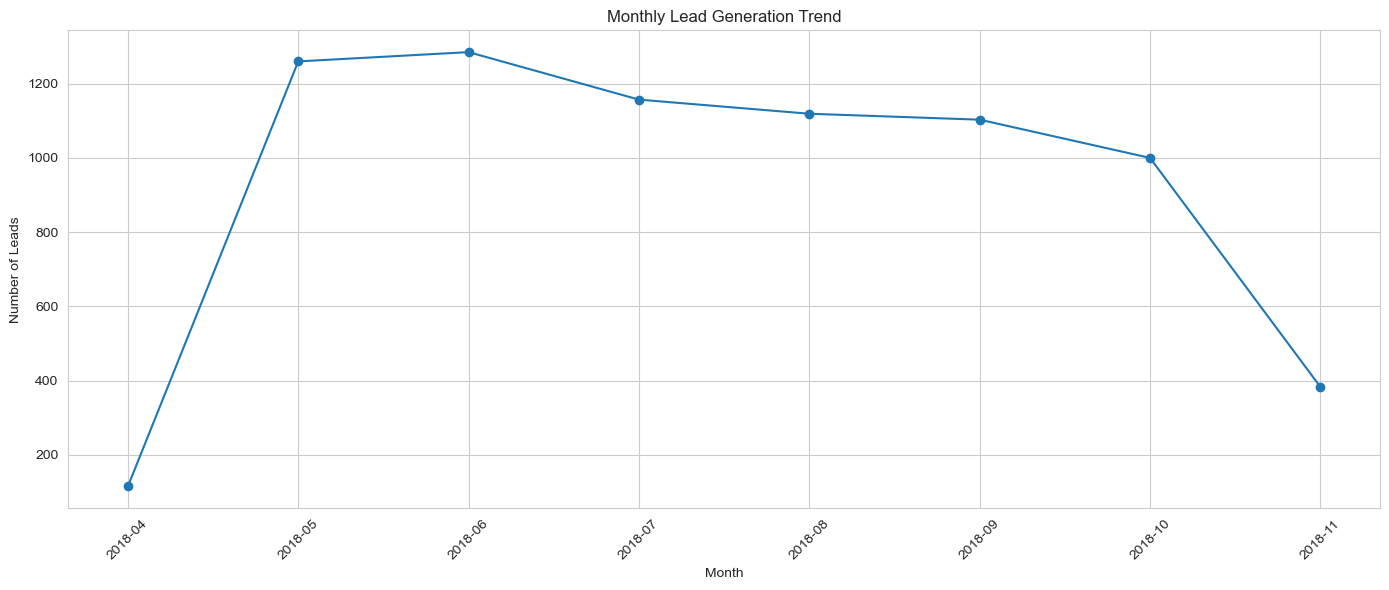

In [25]:
monthly_leads = (
    df.dropna(subset=["Created"])
      .groupby(df["Created"].dt.to_period("M"))
      .size()
)

monthly_leads.index = monthly_leads.index.astype(str)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_leads.index,
    monthly_leads.values,
    marker="o"
)

plt.title("Monthly Lead Generation Trend")
plt.xlabel("Month")
plt.ylabel("Number of Leads")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Machine Learning – Lead Category Prediction

## Target Definition

The dataset does not contain a separate `Lead_Category` column.

Therefore, the business interpretation of `Status` is used to create the target:

### High Potential

- CONVERTED
- POTENTIAL
- IN PROGRESS POSITIVE

### Low Potential

- JUNK LEAD
- LOST
- IN PROGRESS NEGATIVE
- NOT RESPONDING
- JUST ENQUIRY
- LONG TERM

### Open

`OPEN` is excluded from model training because it does not provide sufficient information to confidently classify the lead as High Potential or Low Potential.

## Leakage Prevention

`Status` is the source used to create the target.

Therefore, after creating `Lead_Category`, the original `Status` column is completely excluded from the ML feature set.

This prevents target leakage.

## 22. Create the Target Variable

The `Status` values are standardized first so that differences such as `converted` and `CONVERTED` are treated consistently.

In [26]:
df["Status_Clean"] = (
    df["Status"]
    .astype(str)
    .str.strip()
    .str.upper()
)

high_potential_status = [
    "CONVERTED",
    "POTENTIAL",
    "IN PROGRESS POSITIVE"
]

low_potential_status = [
    "JUNK LEAD",
    "LOST",
    "IN PROGRESS NEGATIVE",
    "NOT RESPONDING",
    "JUST ENQUIRY",
    "LONG TERM"
]

df["Lead_Category"] = np.nan

df.loc[
    df["Status_Clean"].isin(high_potential_status),
    "Lead_Category"
] = "High Potential"

df.loc[
    df["Status_Clean"].isin(low_potential_status),
    "Lead_Category"
] = "Low Potential"

## 23. Check Target Distribution

The number of High Potential and Low Potential leads is checked before model training.

Lead_Category
Low Potential     5137
High Potential    2203
NaN                 82
Name: count, dtype: int64

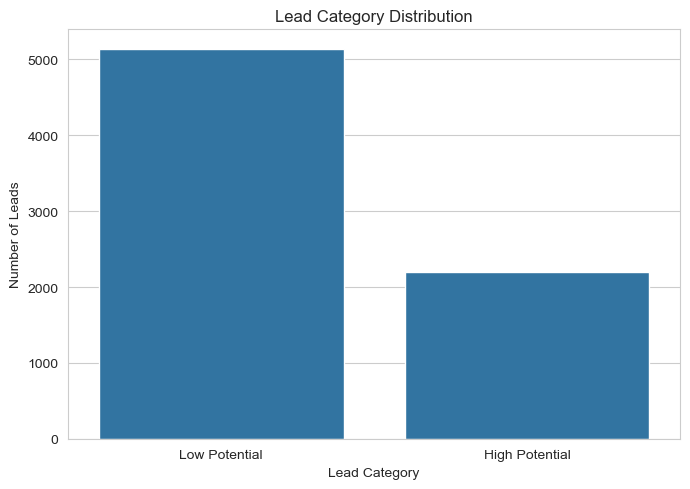

In [27]:
target_counts = df["Lead_Category"].value_counts(dropna=False)

display(target_counts)

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Lead_Category",
    order=["Low Potential", "High Potential"]
)

plt.title("Lead Category Distribution")
plt.xlabel("Lead Category")
plt.ylabel("Number of Leads")
plt.tight_layout()
plt.show()

## 24. Remove Unclassified Leads

Rows corresponding to `OPEN` or any other status that cannot be mapped confidently to High Potential or Low Potential are removed from the modeling dataset.

This prevents arbitrary target labeling.

In [28]:
model_df = df.dropna(
    subset=["Lead_Category"]
).copy()

print("Original dataset shape:", df.shape)
print("Modeling dataset shape:", model_df.shape)

print("\nTarget distribution:")
print(model_df["Lead_Category"].value_counts())

Original dataset shape: (7422, 15)
Modeling dataset shape: (7340, 15)

Target distribution:
Lead_Category
Low Potential     5137
High Potential    2203
Name: count, dtype: int64


## 25. Prepare Target Variable

The target is converted into binary values:

- 0 = Low Potential
- 1 = High Potential

In [29]:
model_df["Target"] = (
    model_df["Lead_Category"]
    .map({
        "Low Potential": 0,
        "High Potential": 1
    })
    .astype(int)
)

print(model_df["Target"].value_counts())

Target
0    5137
1    2203
Name: count, dtype: int64


## 26. Prepare Machine Learning Features

`Status`, `Status_Clean`, `Lead_Category`, and `Target` are excluded from the feature set.

This is the most important leakage-prevention step.

The model will therefore learn from information available about the lead without directly seeing its final sales status.

In [30]:
drop_columns = [
    "Status",
    "Status_Clean",
    "Lead_Category",
    "Target"
]

X = model_df.drop(
    columns=drop_columns
)

y = model_df["Target"]

print("Feature columns used for Machine Learning:")
print(X.columns.tolist())

print("\nTarget column:", "Target")

Feature columns used for Machine Learning:
['Created', 'Product_ID', 'Source', 'Mobile', 'EMAIL', 'Sales_Agent', 'Location', 'Delivery_Mode', 'Created_Year', 'Created_Month', 'Created_Day', 'Created_DayOfWeek']

Target column: Target


## 27. Verify That Target Leakage Is Prevented

The `Status` column must not be present in the Machine Learning features.

In [31]:
if "Status" in X.columns:
    raise ValueError("Target leakage detected: Status is present in X.")

if "Status_Clean" in X.columns:
    raise ValueError("Target leakage detected: Status_Clean is present in X.")

print("Leakage check passed.")
print("Status is NOT used as a Machine Learning feature.")

Leakage check passed.
Status is NOT used as a Machine Learning feature.


## 28. Identify Numerical and Categorical Features

Numerical variables and categorical variables are handled separately during preprocessing.

In [32]:
numeric_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Created_Year', 'Created_Month', 'Created_Day', 'Created_DayOfWeek']

Categorical features:
['Product_ID', 'Source', 'Mobile', 'EMAIL', 'Sales_Agent', 'Location', 'Delivery_Mode']


## 29. Train-Test Split

The data is split into training and testing sets.

Stratification is used to maintain a similar High Potential / Low Potential ratio in both datasets.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training data shape: (5872, 12)
Testing data shape: (1468, 12)

Training target distribution:
Target
0    0.699932
1    0.300068
Name: proportion, dtype: float64

Testing target distribution:
Target
0    0.699591
1    0.300409
Name: proportion, dtype: float64


## 30. Data Preprocessing Pipeline

### Numerical Features

Missing numerical values are replaced using the median.

### Categorical Features

Missing categorical values are replaced with the most frequent value and categorical variables are converted into numerical form using One-Hot Encoding.

The preprocessing is fitted only on the training data through the Pipeline, preventing information leakage from the test set.

In [34]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Model Building

The following classification algorithms are evaluated:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting

Class balancing is used where supported to improve learning for the minority High Potential class.

In [35]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42,
        class_weight="balanced"
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        random_state=42,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        max_depth=3,
        random_state=42
    )
}

## 31. Train and Evaluate Models

Each model is placed inside the same preprocessing pipeline.

The primary model-selection metric is **F1 Score** because the target classes are imbalanced.

Accuracy alone is not sufficient for selecting the best model.

In [36]:
model_results = []

fitted_models = {}

for model_name, model in models.items():

    print("=" * 60)
    print("Training:", model_name)

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    if model_name == "Gradient Boosting":
        sample_weights = np.where(y_train == 1, 2.0, 1.0)

        pipeline.fit(
            X_train,
            y_train,
            model__sample_weight=sample_weights
        )
    else:
        pipeline.fit(
            X_train,
            y_train
        )

    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    fitted_models[model_name] = pipeline

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))

Training: Logistic Regression
Accuracy : 0.7309
Precision: 0.5395
Recall   : 0.712
F1 Score : 0.6139
Training: Decision Tree
Accuracy : 0.6805
Precision: 0.4783
Recall   : 0.6984
F1 Score : 0.5677
Training: Random Forest
Accuracy : 0.7589
Precision: 0.6043
Recall   : 0.5714
F1 Score : 0.5874
Training: Gradient Boosting
Accuracy : 0.7425
Precision: 0.5624
Recall   : 0.644
F1 Score : 0.6004


## 32. Model Performance Comparison

The performance of all trained models is compared using Accuracy, Precision, Recall, and F1 Score.

In [37]:
model_results = pd.DataFrame(model_results)

model_results = model_results.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

display(model_results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.730926,0.539519,0.712018,0.613881
1,Gradient Boosting,0.742507,0.562376,0.643991,0.600423
2,Random Forest,0.758856,0.604317,0.571429,0.587413
3,Decision Tree,0.680518,0.478261,0.698413,0.567742


## 33. Visualize Model Performance

F1 Score is used as the primary comparison metric because the dataset contains an imbalanced target distribution.

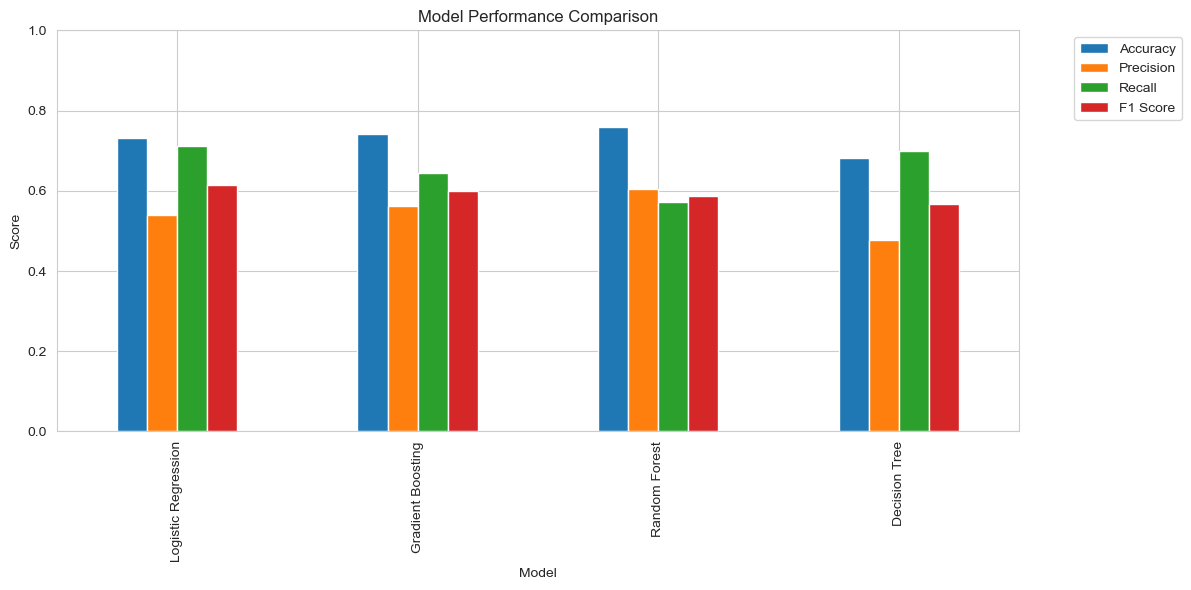

In [38]:
model_results_plot = model_results.set_index("Model")

model_results_plot[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(12, 6),
    ylim=(0, 1),
    title="Model Performance Comparison"
)

plt.xlabel("Model")
plt.ylabel("Score")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 34. Select the Best Model

The model with the highest F1 Score is selected as the final model.

In [39]:
best_model_name = model_results.loc[
    model_results["F1 Score"].idxmax(),
    "Model"
]

best_f1_score = model_results.loc[
    model_results["F1 Score"].idxmax(),
    "F1 Score"
]

best_model = fitted_models[best_model_name]

print("Best Model:", best_model_name)
print("Best F1 Score:", round(best_f1_score, 4))

Best Model: Logistic Regression
Best F1 Score: 0.6139


## 35. Detailed Evaluation of the Best Model

The selected model is evaluated using:

- Confusion Matrix
- Classification Report
- Accuracy
- Precision
- Recall
- F1 Score

In [40]:
best_pred = best_model.predict(X_test)

print("Best Model:", best_model_name)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        best_pred,
        target_names=["Low Potential", "High Potential"],
        zero_division=0
    )
)

Best Model: Logistic Regression

Classification Report:
                precision    recall  f1-score   support

 Low Potential       0.86      0.74      0.79      1027
High Potential       0.54      0.71      0.61       441

      accuracy                           0.73      1468
     macro avg       0.70      0.73      0.70      1468
  weighted avg       0.76      0.73      0.74      1468



## 36. Confusion Matrix

The confusion matrix shows the number of correctly and incorrectly classified High Potential and Low Potential leads.

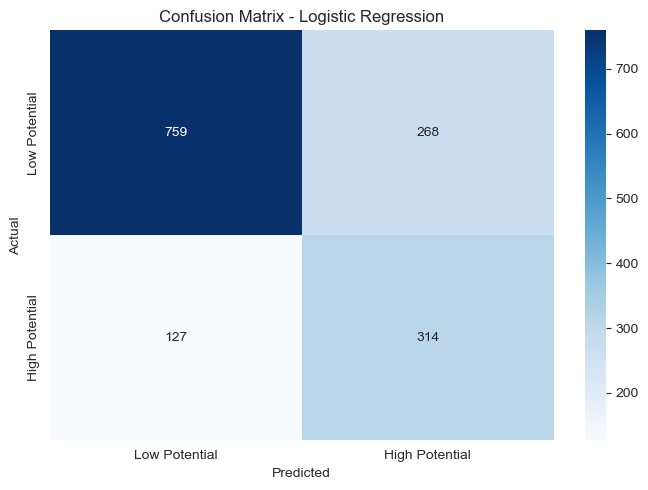

In [41]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Potential", "High Potential"],
    yticklabels=["Low Potential", "High Potential"]
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 37. Final Model Metrics

The final metrics of the selected model are displayed separately for easy reporting.

In [42]:
final_accuracy = accuracy_score(y_test, best_pred)

final_precision = precision_score(
    y_test,
    best_pred,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    best_pred,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    best_pred,
    zero_division=0
)

final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1
    ]
})

display(final_metrics)

,Metric,Score
0,Accuracy,0.730926
1,Precision,0.539519
2,Recall,0.712018
3,F1 Score,0.613881


# Business Insights

Based on the exploratory analysis, the following areas can be used to improve sales effectiveness:

- Identify lead sources producing a higher proportion of converted leads.
- Monitor the performance and workload of sales agents.
- Analyze locations generating a larger number of leads.
- Understand which products attract the highest number of leads.
- Compare delivery modes and their relationship with lead outcomes.
- Use mobile and email availability as indicators of lead contactability.
- Analyze monthly lead-generation trends to identify periods of higher or lower activity.
- Use the Machine Learning model to pre-categorize incoming leads into High Potential and Low Potential categories.

The Machine Learning model should support sales staff during the initial lead conversation rather than relying only on post-analysis.

# Conclusion

This project analyzed FicZon Inc's sales lead data and developed a Machine Learning approach for lead quality prediction.

The original `Status` variable was used only to construct the target variable `Lead_Category`. It was then completely excluded from the Machine Learning features to prevent target leakage.

The final dataset was preprocessed using a Scikit-learn pipeline, and multiple classification algorithms were compared using F1 Score along with Accuracy, Precision, and Recall.

The model with the highest F1 Score was selected as the final model.

The resulting solution can help FicZon prioritize High Potential leads earlier in the sales process and support sales teams in improving sales effectiveness.